
<font color=#009afa size=50>Visualisation of Data</font>

<font size=50>DAT5001 - Satellites</font>

CHECK THIS BELOW!

|**Assessment Code:** |PRES1|
|---|---|
|**Author:**|Tom Rowan, ST20285213|
|**Course:**| DAT5001_S2_25|
|**Course Tutor:**| ***** Dr. Imtiaz *****|

For this assignment, students will use content from the PRES1 presentation to deliver an individual report.  The report will include following parts:

Part 1 (Introduction): Outlining the issue with background information. Questions/Hypothesis/Objective/Message/Goal related to the issue addressed by this report.  

Part 2 (Materials and Methods): Description of data which includes data collection, cleaning and transformation procedures along with description about the data context/metadata.  Design principles and tools used to create the storyboard and infographics. 

Part 3 (Results): Figures and description narrating the issue in detail, particularly summarised view (both spatial and temporal) of the issue across different locations and time points as well as comparative view.   

Part 4 (Discussion): Identification of key bottlenecks associated with the issue evident from the results.  Also provide rationale for the Questions /Hypothesis /Objective /Message /Goal.

## Part 1

Issues:
- Kessler Syndrome (https://aquarid.physics.uwo.ca/kessler/Kessler%20Syndrome-AAS%20Paper.pdf)
- Rocket Launches - CO2 impact

Falcon 9 Rocket (https://sma.nasa.gov/LaunchVehicle/assets/spacex-falcon-9-data-sheet.pdf)

Copilot says:

A single SpaceX Falcon 9 launch uses approximately 507,500 kilograms (about 507.5 metric tonnes) of propellant, which consists of:

RP-1 (rocket-grade kerosene): ~112,184 kg
Liquid Oxygen (LOX): ~395,316 kg

This total is based on the Falcon 9 Full Thrust (Block 5) version, which is the current operational variant. The rocket is a two-stage launch vehicle, and both stages use RP-1 and LOX as propellants.
Breakdown by Stage

First Stage:

Propellant mass: ~395,700 kg
Burn time: ~162 seconds
Engines: 9 Merlin 1D


Second Stage:

Propellant mass: ~92,670 kg
Burn time: ~397 seconds
Engine: 1 Merlin Vacuum



These figures are derived from technical specifications and performance analyses. [wevolver.com]
Environmental Impact
Each Falcon 9 launch emits approximately 336,552 kg of CO₂, based on the combustion of RP-1 kerosene. [championtraveler.com]
Sources

Wevolver Falcon 9 Block 5 Specs [wevolver.com]
Champion Traveler CO₂ Analysis [championtraveler.com]
Wikipedia Falcon 9 Overview [en.wikipedia.org]

As of October 2025, SpaceX typically launches 28 Starlink satellites per Falcon 9 mission. [extremetech.com], [arstechnica.com], [msn.com]
This number has decreased over time due to the satellites becoming larger and more capable. Earlier in the Starlink program (around 2019–2020), Falcon 9 launches carried up to 60 satellites per flight. However, the current V2 Mini satellites are more advanced and heavier, which limits the number that can be carried per launch.

https://www.extremetech.com/aerospace/spacex-sends-10000th-starlink-satellite-into-orbit-with-latest-falcon-9




 D.J. Kessler and B.G. Cour-Palais, "Collision Frequency of Artificial Satellites: The Creation of a Debris Belt", Journal of Geophysical Research, Vol. 83, No. A6, pp. 2637-2646, June 1, 1978. 
Available at: https://www.freelists.org/archives/arocket/05-2025/pdfhf1FIX9bCw.pdf
Accessed 22/10/2025




## Code for Graphs below

In [2]:
# Install Requirements Using Pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Standard Libraries
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# Pycountry 
import pycountry

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Beautifulsoup
from bs4 import BeautifulSoup

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

In [4]:
re_df = pd.read_csv('../../datasets/Reentry_History_Spreadsheet_09-29-25.csv')
sat_df = pd.read_csv('../../datasets/UCS-Satellite-Database 5-1-2023.csv')

In [5]:
re_df.columns

Index(['Observed Reentry Date (UTC)', 'Object Name',
       'International Designator', 'SSN', 'TLE Epoch (UTC)',
       'Aerospace Reentry Prediction (UTC)',
       'Aerospace Stated Uncertainty 20% Rule (+/- hrs)', 'Country of Origin',
       'Type', 'Sighting Location', 'Sighting Latitude', 'Sighting Longitude',
       'Debris Recovery Location', 'Recovery Latitude', 'Recovery Longitude'],
      dtype='object')

In [6]:
sat_df.columns

Index(['Name of Satellite, Alternate Names',
       'Current Official Name of Satellite', 'Country/Org of UN Registry',
       'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose',
       'Detailed Purpose', 'Class of Orbit', 'Type of Orbit',
       'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)',
       'Eccentricity', 'Inclination (degrees)', 'Period (minutes)',
       'Launch Mass (kg.)', ' Dry Mass (kg.) ', 'Power (watts)',
       'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor',
       'Country of Contractor', 'Launch Site', 'Launch Vehicle',
       'COSPAR Number', 'NORAD Number', 'Comments', 'Unnamed: 28',
       'Source Used for Orbital Data', 'Source', 'Source.1', 'Source.2',
       'Source.3', 'Source.4', 'Source.5', 'Source.6', 'Unnamed: 37',
       'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41',
       'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45',
       'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49',


NB: Need to clean the data so that we only have satellites, removing the rockets and other debris.

In [7]:
# Join raw data set
df = sat_df.set_index('COSPAR Number').join(re_df.set_index('International Designator'))
df.reset_index(inplace=True)

In [8]:
display (df.loc[df['COSPAR Number'] == '2021-009BM'])

,COSPAR Number,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,...,Aerospace Reentry Prediction (UTC),Aerospace Stated Uncertainty 20% Rule (+/- hrs),Country of Origin,Type,Sighting Location,Sighting Latitude,Sighting Longitude,Debris Recovery Location,Recovery Latitude,Recovery Longitude
3922,2021-009BM,Starlink-2025,Starlink-2025,USA,USA,SpaceX,Commercial,Communications,NaN,LEO,...,2025-03-25T04:08:05.960000Z,1.0,UNITED STATES OF AMERICA,Payload,"California and Utah, USA",38.83,-119.63,NaN,NaN,NaN


In [9]:
payload_count = df['Type'].value_counts().reset_index()
payload_count.columns = ['Type', 'Count']
display(payload_count)

,Type,Count
0,Payload,764
1,PAYLOAD,13
2,Unknown,11
3,R/B,3
4,DEBRIS,2
5,ROCKET BODY,1


In [10]:
contractor_counts = df['Contractor'].value_counts().reset_index()
contractor_counts.columns = ['Contractor', 'Count']
display(contractor_counts)

,Contractor,Count
0,SpaceX,3997
1,OneWeb Satellites/Airbus,502
2,"Planet Labs, Inc.",199
3,China Academy of Space Technology (CAST),182
4,Spire Global,135
...,...,...
572,Care Weather Technologies/Brigham Young Univer...,1
573,Visiona Tecnologia Espacial,1
574,China Academy of Science,1
575,China Great Wall Industry Corporation (CGWIC),1


<Axes: xlabel='Contractor'>

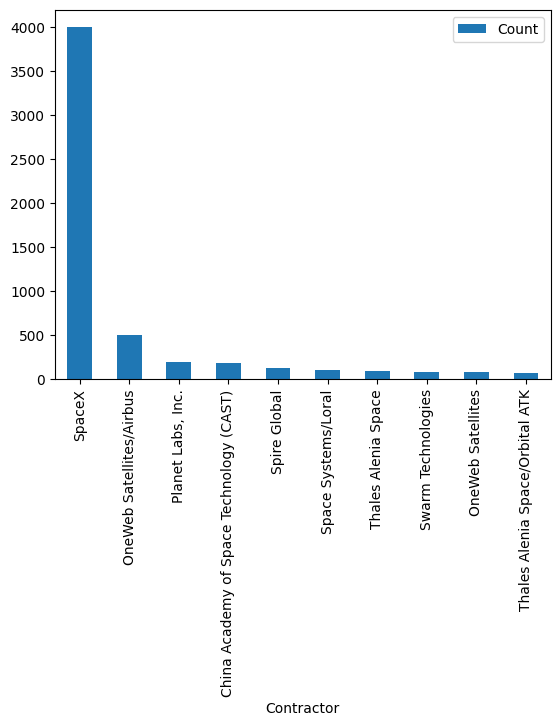

In [11]:
contractor_counts.head(10).plot(kind='bar', x='Contractor')

## Feature Engineering

In [12]:
df['Year of Launch'] = df['Date of Launch'].astype(str).str[-4:]
#df['Year of Launch'] = df['Year of Launch'].astype(int)

In [13]:
df.to_csv('working_dataset.csv')

In [14]:
year_counts = df['Year of Launch'].value_counts().reset_index().sort_values(by='Year of Launch')
year_counts.columns = ['Year of Launch', 'Count']
year_counts.dropna
display(year_counts)

,Year of Launch,Count
34,/018,1
33,1974,1
37,1988,1
35,1989,1
31,1990,2
38,1991,1
36,1992,1
28,1993,3
32,1994,2
27,1995,4


<Axes: xlabel='Year of Launch'>

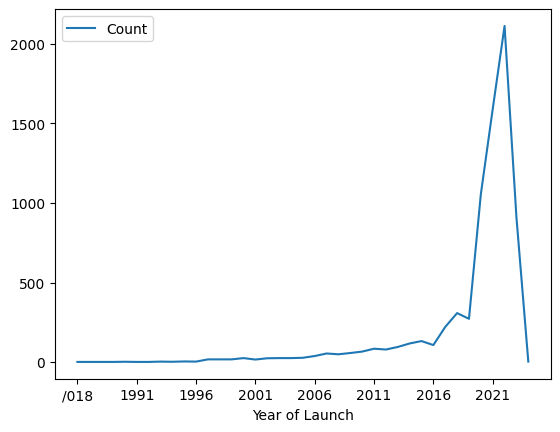

In [15]:
year_counts.plot(kind='line', x='Year of Launch')

## Scraping More Data

https://www.n2yo.com/satellite/?s=65909

API Key:  6UGT66-UVJVBR-RE9FV6-5L9M

Reference:
https://www.n2yo.com/satellite-article/How-many-satellites-can-we-safely-fit-in-Earth-orbit/86

In [16]:
def fetch_proxy_list (proxy_list_url="https://raw.githubusercontent.com/proxifly/free-proxy-list/refs/heads/main/proxies/countries/GB/data.txt"):

    # Fetch the list of proxies
    all_proxies = []
    http_proxies = []

    # Wrap in a try/except/finally block
    try:
        print (Fore.CYAN + "[Info] Fetching list of proxies." + Fore.RESET)
        response = requests.get(proxy_list_url)
        if response.status_code == 200:
            all_proxies = response.text.split("\n")

            for proxy in all_proxies:
                if proxy.startswith("http"):
                    http_proxies.append(proxy)
        else:
            print (Fore.RED + "[Error] Failed to fetch list of proxies.")
            print (f"[Error] {response.status_code}" + Fore.RESET) 

    except Exception as e:
        print (Fore.RED + "[Error] Error fetching proxies." )
        print (f"[Error] {e}" + Fore.RESET)

    finally:
        print (Fore.YELLOW + f"[Info] Got {len(http_proxies)} proxies." + Fore.RESET)
        return http_proxies


# Get a random proxy from the list
def get_random_proxy (http_proxies):
    return random.choice(http_proxies)

In [17]:
base_url = "https://www.n2yo.com/satellite/?s="
last = 65909 # maybe more - detect failure to find a satellite

In [18]:
def parse_satinfo(html):

    soup = BeautifulSoup(html, 'html.parser', from_encoding='utf-8')
    satinfo_div = soup.find('div', id='satinfo')

    if satinfo_div:

        sat_data = {}

        # Extract satellite name
        h1 = satinfo_div.find('h1')
        sat_data['name'] = h1.text.strip() if h1 else None

        # Extract all <b> tags and their following text
        for b_tag in satinfo_div.find_all('b'):
            key = b_tag.text.strip().replace(':', '')
            if not key.startswith('Note'):   
                if key == "Launch date":
                    # Look for the next <a> tag after the <b> tag
                    a_tag = b_tag.find_next('a')
                    value = a_tag.text.strip() if a_tag else None
                else:    
                    value = b_tag.next_sibling
            
                if value:
                    sat_data[key] = value.strip().replace(': ', '')
            #else:
                #sat_data.pop(key)

    return sat_data



In [19]:
sat_data_combined = []

proxy_list = fetch_proxy_list()
#65910
# for page in range (1, 65910):  
    
#    # Get a random proxy from the list
#    proxy = get_random_proxy(proxy_list)
#    proxies = {'http': proxy}

#    url = base_url + str(page)
    
#    # Fetch the page
#    response = requests.get (url=url, proxies = proxies)
#    satellite_info = parse_satinfo(response.content)
#    sat_data_combined.append(satellite_info)
#    print ('.', end='')
#    if (page % 100 == 0):
#        print (page)


[Info] Fetching list of proxies.
[Info] Got 22 proxies.


In [20]:
new_sat_df = pd.DataFrame(sat_data_combined)
new_sat_df.head(20)
new_sat_df.to_csv('65k_satellites.csv')

https://www.planet4589.org/space/gcat/index.html

tsv Files: 

SatCat: https://www.planet4589.org/space/gcat/tsv/cat/satcat.tsv
Payload: https://www.planet4589.org/space/gcat/tsv/cat/psatcat.tsv   -- enrich with this data
Aux cat: ??? https://www.planet4589.org/space/gcat/tsv/cat/auxcat.tsv
Org Data: https://www.planet4589.org/space/gcat/tsv/tables/orgs.tsv
Launch sites: https://www.planet4589.org/space/gcat/tsv/tables/sites.tsv

Documentation: https://www.planet4589.org/space/gcat/pdf/doc.pdf

Citation is "McDowell, J, 2020: General Catalog of Artificial Space Objects, https://planet4589.org/space/gcat"
Accessed 24/10/2025

Main Object Catalogs
VIII.2.1 Primary Orbital Object Catalogs
VIII.2.1.1 The Standard (S) Satellite Catalog
Since the late 1950s the US government has maintained a catalog of satellites (often referred to as the SATCAT). Each
satellite is given a sequential number (1 was the rocket stage from the first Sputnik). These numbers are sometimes
referred to as SSN numbers.
In GCAT, each entry in the S catalog (Standard Satellite Catalog or satcat) corresponds directly to the
corresponding entry in the US catalog; entry S00001 corresponds to SSN 1, entry S40000 corresponds to SSN 40000.
The S catalog contains additional metadata not present in the US catalog, described later in this chapter. Note that I
will use SATCAT in upper case to refer to the US catalog, while the lower case version will always refer to GCAT’s
S catalog.
By convention I render entries 1-99999 in each catalog with 5 digits, in this case S00001 to S99999. I then
jump to 9 digits for objects 000100000 onwards (S000100000 in this case). I am optimistic that we won’t reach
S999999999 before I retire, so that’ll be Somebody Else’s Problem.
There are, as always, complications. Not infrequently, the SSN numbers associated with two space objects
are swapped, or an SSN number is reassigned to a different object and the previously assigned object is now not
in the catalog. However, archival TLE (Two Line Element) sets for the previous object remain associated with the
same catalog number, potentially causing confusion. Although I would rather not reassign numbers, in the interests
of practical compatibility the S catalog entry corresponds to the object MOST RECENTLY ASSOCIATED with that
catalog number (and the GCAT is updated as required to reflect this).
The SSN number is really associated with an object tracked by the US space tracking team (currently the 18th
Space Control Squadron and associated organizations). The set of TLEs associated with that catalog number, for the
most part, define the SSN. The association of that catalog number with a physical object (satellite, rocket, debris) is
an inference. Sometimes I disagree with the association made, and the S catalog reflects that. The harder problem
is when you have, say, 3 SSN tracked objects and three known payloads, but you have no idea which is which. This
can occur, for example, when three externally similar cubesats deployed from the same vehicle immediately fail, so
even the satellite owners don’t know which is which. In this case the SATCAT will just have them as ’OBJECT C’,
etc., and not attempt to make an identification. I prefer to make an arbitrary assignment of the three objects to catalog
numbers but flag the assignments as uncertain. This lets me enter all the metadata such as country, owner, name etc.
and so statistical counts such as number of payloads associated with a given country will come out right.
Some satellites are made up of several attached sections. When I deem that these separate sections are of
sufficient interest to deserve their own catalog entry (for example because their metadata are interestingly different)
I create additional entries in the auxcat (see below), and choose one of the sections to be associated with the S entry.
As an example, for CORONA satellites both the CORONA payload and the attached Agena rocket stage, as well as
any Agena aft rack attached payloads, get catalog entries. In such cases the S entry is given to the payload; metadata
includes the information that the CORONA and the Agena remained attached until reentry.
The SATCAT associates debris objects with a particular launch but does not identify them in detail; again, I
make my best guess as to the nature and origin of particular debris objects.
The US catalog is coy about certain military and intelligence satellites belonging to the US and its allies.
Usually a cover name (e.g. USA 304) and a launch date are provided, but no orbital data or reentry date. Since I do
not have access to secret information, I am free to speculate. Usually it’s not very hard and identifications of secret
satellites with particular programs and orbits mostly have a high degree of confidence.

 - LDate (Launch Date).
 - SDate Separation Date (or Phase Start Date).
 - DDate Descent Date (or Phase End Date).
 - ODate Orbit Epoch Date (Epoch of canonical orbital data)
 - Status: O, R ... ?
 - Length, Diameter, Span, 
 - Piece COSPAR Designation
 - Name Name in UN satellite registry
 - Class (Amateur, Business, Civil (Gov, non-mil), Defence (Gov, mil or intel))

Category:

- AST Astronomy
- BIO Biology and life sciences
- CAL Calibration (for atmospheric density, space surveillance radars, etc). Usually passive.
- COM Communications
- EDU Educational purposes.
- EOSCI Earth observing science, except imaging
- EW Missile early warning, including ballistic missile defence tracking
- GEOD Geodesy
- IMG Imaging (optical), except meteorology
- IMG-R Imaging (radar)
- INF Infrastructure (support structures, deployers etc)
- MET Meteorology (imaging)
- MET-RO Meteorology (radio occultation)
- MGRAV Microgravity experiments
- MISC Miscellaneous (e.g. burial services)
- NAV Navigation, positioning and timing
- PLAN Deep space related mission
- RB Rocket body (rocket upper stage)
- RV Reentry vehicle
- SCI Scientific studies, except astronomy and Earth observing
- SIG Signals intelligence
- SS Spaceship, i..e human spaceflight related (including cargo ships)
- TARG Target for missile defense or antisatellite tests
- TECH Technology and training
- WEAPON Weapon, including antisatellite experiment and FOB



In [21]:
#satcat_df = pd.read_csv('../../datasets/satcat.tsv', sep='\t')
satcat_df = pd.read_csv('https://www.planet4589.org/space/gcat/tsv/cat/satcat.tsv', sep='\t')
pay_df = pd.read_csv('https://www.planet4589.org/space/gcat/tsv/cat/psatcat.tsv', sep='\t')
orgs_df = pd.read_csv('https://www.planet4589.org/space/gcat/tsv/tables/orgs.tsv', sep='\t')
lsite_df = pd.read_csv('https://www.planet4589.org/space/gcat/tsv/tables/sites.tsv', sep='\t')

In [22]:
satcat_df.shape

(66206, 42)

In [23]:
satcat_df.sample(n=10)

,#JCAT,Satcat,Launch_Tag,Piece,Type,Name,PLName,LDate,Parent,SDate,...,ODate,Perigee,PF,Apogee,AF,Inc,IF,OpOrbit,OQUAL,AltNames
32393,S32393,32393,2007-065,2007-065A,P,Kosmos-2434,Uragan-M No. 21L,2007 Dec 25,S32396,2007 Dec 25 2302,...,2007 Dec 27,19124,,19133,,64.66,,MEO,-,"Glonass-M 721,14F113 No. 794-35-821:RA"
17626,S17626,17626,1981-053,1981-053KV,D B,deb Kosmos-1275,-,1981 Jun 4,S12504,1981 Jul 24 2351,...,1993 Aug 5,953,,1185,,82.86,,LEO/I,-,-
28681,S28681,28681,1992-047,1992-047AE,D P,deb DM2-63L SOZ-2,-,1992 Jul 30,S22067,1994 Nov 8,...,2005 May 5,998,,16735,,67.95,,HEO,-,-
15596,S15596,15596.0,1985-021,1985-021B,C M,OIS,Star 27 S/N 0056,1985 Mar 13,R51516,1985 Mar 13 0211?,...,1985 Nov 5,757.0,,816,,108.04,,LEO/R,-,-
28638,S28638,28638,2005-012,2005-012A,P,Apstar 6,Apstar 6,2005 Apr 12,S28639,2005 Apr 12 1225,...,2005 Jun 11,35784,,35788,,0.02,,GEO/S,-,-
44409,S44409,44409,2019-038,2019-038Z,P,Lemur-2-EJatta,Lemur FM104,2019 Jul 5,A09444,2019 Jul 5 1000?,...,2019 Jul 8,515,,546,,97.49,,LLEO/S,-,-
5166,S05166,5166.0,1971-032,1971-032E,D O,deb Salyut,-,1971 Apr 19,S05160,1971 Apr 19 0150?,...,1971 Apr 21,190.0,,260,,51.62,,LLEO/I,-,-
3153,S03153,3153.0,1968-020,1968-020B,P,LAMPAN I,P-11 No. 4411,1968 Mar 14,A01329,1968 Mar 14 2339?,...,1968 Apr 15,472.0,,520,,83.1,,LLEO/I,-,"NRO Mission 7322,OPS 7076"
38075,S38075,38075,2012-005,2012-005A,P,Navid-e Elm-o Sanat,Navid,2012 Feb 3,S38076,2012 Feb 3 0011?,...,2012 Feb 5,275,,373,,56.02,,LLEO/I,-,-
19283,S19283,19283,1988-058,1988-058C,C M,D-2-2L SOZ-1,SOZ,1988 Jul 7,S19282,1988 Jul 7 1858?,...,1988 Jul 8,169,,188,,51.54,,LLEO/I,-,-


In [24]:
satcat_df.columns

Index(['#JCAT', 'Satcat', 'Launch_Tag', 'Piece', 'Type', 'Name', 'PLName',
       'LDate', 'Parent', 'SDate', 'Primary', 'DDate', 'Status', 'Dest',
       'Owner', 'State', 'Manufacturer', 'Bus', 'Motor', 'Mass', 'MassFlag',
       'DryMass', 'DryFlag', 'TotMass', 'TotFlag', 'Length', 'LFlag',
       'Diameter', 'DFlag', 'Span', 'SpanFlag', 'Shape', 'ODate', 'Perigee',
       'PF', 'Apogee', 'AF', 'Inc', 'IF', 'OpOrbit', 'OQUAL', 'AltNames'],
      dtype='object')

In [25]:
columns_to_keep = ['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State', 'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape', 'Perigee', 'Apogee', 'Inc']

sdf = satcat_df[columns_to_keep]
sdf.columns

Index(['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State',
       'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape',
       'Perigee', 'Apogee', 'Inc'],
      dtype='object')

Feature engineering with dates.

In [26]:
sdf['LDate'] = sdf['LDate'].replace("-", np.nan)  # Shouldn't be any!
sdf = sdf.dropna(subset=['LDate'])
sdf['DDate'] = sdf['DDate'].replace("-", np.nan)

# Modify date columns
# Convert to datetime format
sdf['LDate'] = pd.to_datetime(sdf['LDate'], errors='coerce')
sdf['DDate'] = pd.to_datetime(sdf['DDate'], errors='coerce')

# Create a Year of Launch and Descent
sdf['LYear'] = sdf['LDate'].dt.year.astype('Int64')
sdf['DYear'] = sdf['DDate'].dt.year.astype('Int64')

# Replace null DDate with today's date
today = pd.Timestamp(datetime.today())
sdf['EffectiveDDate'] = sdf['DDate'].fillna(today)

# Calculate lifetime
delta = sdf['EffectiveDDate'] - sdf['LDate']
sdf['ActiveDays'] = delta.dt.days
sdf['ActiveMonths'] = (delta.dt.days / 30.44).round(1)  # Approximate month length
sdf['ActiveYears'] = (delta.dt.days / 365.25).round(2)  # Account for leap years

# Format as dd/mm/yyyy (because we are British)
sdf['LDate'] = sdf['LDate'].dt.strftime('%d/%m/%Y')
sdf['DDate'] = sdf['DDate'].dt.strftime('%d/%m/%Y')

In [27]:
# Convert alpha-2 to alpha-3
def alpha2_to_alpha3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None
    

# Apply conversion to your State column
sdf['CountryCode'] = sdf['State'].apply(alpha2_to_alpha3)

In [28]:
# Type field - Remove Sub-Types
sdf['Type'] = sdf['Type'].str[0]

- P Payload (for orbital attempt)
- C Component
- R Launch vehicle stage
- D Fragmentation debris
- S Suborbital payload (e.g. sounding rocket payload or
missile reentry vehicle)
- X Catalog entry that has been deleted (used in auxcat etc.)
- Z Spurious catalog entry (was in SATCAT, perhaps in
TLEs, but there was no real object)

In [29]:
type_counts = sdf['Type'].value_counts().sort_index()
display(type_counts)

Type
C     7903
D    27825
P    24213
R     6180
Z       26
Name: count, dtype: int64

In [30]:
type_json = {
  "P": "Payload",
  "C": "Component",
  "R": "Rocket Body",
  "D": "Debris",
  "S": "Suborbital payload",
  "X": "Deleted Object",
  "Z": "Spurious Entry"
}

In [31]:
# Remove X and Z objects
sdf = sdf[~sdf['Type'].isin(['X', 'Z'])]

# Map the description to a new column
sdf['TypeDesc'] = sdf['Type'].map(type_json)

In [65]:
type_counts = sdf['TypeDesc'].value_counts().sort_index()
display(type_counts)

TypeDesc
Component       7903
Debris         27825
Payload        24213
Rocket Body     6180
Name: count, dtype: int64

<Axes: xlabel='TypeDesc'>

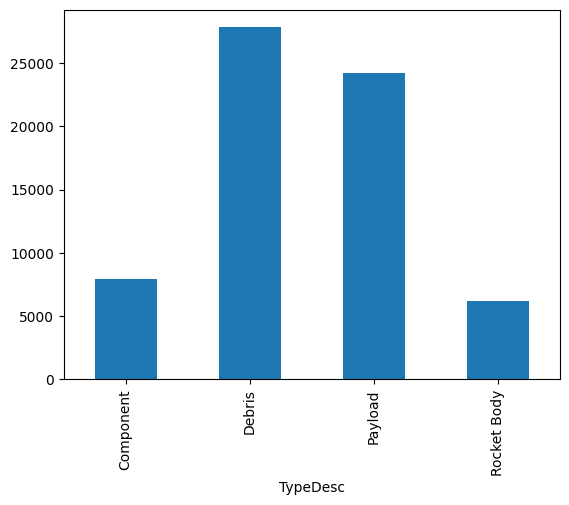

In [66]:
type_counts.head(10).plot(kind='bar', x='TypeDesc')

In [33]:
sdf.sample(n=10)

,Piece,Type,Name,LDate,DDate,Status,Owner,State,Manufacturer,Mass,...,Apogee,Inc,LYear,DYear,EffectiveDDate,ActiveDays,ActiveMonths,ActiveYears,CountryCode,TypeDesc
34206,1999-057RH,D,deb ZY-1 01,14/10/1999,20/08/2012,R,CNSA,CN,-,0,...,745,98.25,1999,2012,2012-08-20 00:00:00.000000,4694.0,154.2,12.85,CHN,Debris
22477,1992-093FS,D,deb 11S772,25/12/1992,28/06/2025,R,RVSNR,RU,-,0.0,...,882,70.89,1992,2025,2025-06-28 00:00:00.000000,11873.0,390.0,32.51,RUS,Debris
22963,1994-002A,P,Gals 1,20/01/1994,NaN,N,INFK/LAND,RU,NPOPMR,2600.0,...,35792,0.19,1994,<NA>,2025-10-27 09:16:45.707789,11603.0,381.2,31.77,RUS,Payload
62584,2025-007K,P,Weili Kongjian 01-09,13/01/2025,NaN,O,CENTI,CN,HITSAT,140,...,652,54.98,2025,<NA>,2025-10-27 09:16:45.707789,287.0,9.4,0.79,CHN,Payload
54025,2022-127C,R,Electron 31 Stage 2,07/10/2022,27/02/2023,R,RLABN,NZ,RLABN,250,...,767,98.34,2022,2023,2023-02-27 13:53:00.000000,143.0,4.7,0.39,NZL,Rocket Body
10025,1977-041B,R,Centaur AC-39,26/05/1977,NaN,O,LERC,US,GDC,2000.0,...,36337,21.89,1977,<NA>,2025-10-27 09:16:45.707789,17686.0,581.0,48.42,USA,Rocket Body
44781,2019-076C,P,Ningxia-1 03 xing,13/11/2019,NaN,O,NINGX/CASC,CN,DFHZ,100,...,898,45.00,2019,<NA>,2025-10-27 09:16:45.707789,2175.0,71.5,5.95,CHN,Payload
55110,2023-001DF,P,Astrocast-0401,03/01/2023,NaN,O,ACAST,CH,ACAST,4.500,...,551,98.23,2023,<NA>,2025-10-27 09:16:45.707789,1028.0,33.8,2.81,CHE,Payload
21850,1992-003D,R,Blok-2BL 23-692,24/01/1992,13/12/2006,R,RVSNR,RU,NPOE,4500.0,...,39147,62.87,1992,2006,2006-12-13 00:00:00.000000,5437.0,178.6,14.89,RUS,Rocket Body
12736,1981-053CD,D,deb Kosmos-1275,04/06/1981,NaN,O,VMF,SU,-,0.0,...,1174,83.03,1981,<NA>,2025-10-27 09:16:45.707789,16216.0,532.7,44.40,None,Debris


In [34]:
# Is the satellite still orbiting?
sdf['Active'] = sdf['DDate'].isnull()
ddate_counts = sdf['Active'].value_counts().reset_index()
ddate_counts.columns = ['Active', 'Count']
display(ddate_counts)

,Active,Count
0,True,34370
1,False,31751


In [35]:
avg_lifetime = sdf[sdf['Type'].str.startswith('P', na=False)].groupby('CountryCode')['ActiveYears'].mean().reset_index()
avg_lifetime.columns = ['CountryCode', 'AvgLifetime']
avg_lifetime = avg_lifetime.sort_values('AvgLifetime', ascending=False).head(20)

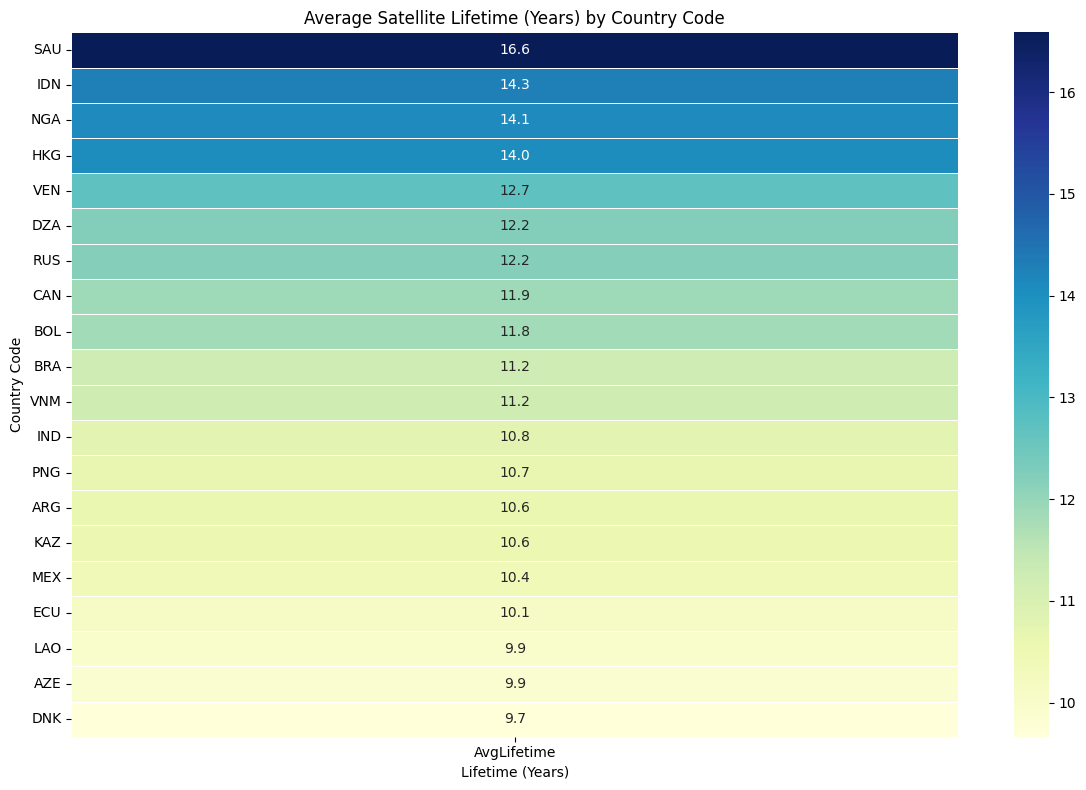

In [36]:

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(
    avg_lifetime.set_index('CountryCode'),
    annot=True,
    cmap='YlGnBu',
    fmt=".1f",
    linewidths=0.5,
)
plt.title('Average Satellite Lifetime (Years) by Country Code')
plt.ylabel('Country Code')
plt.xlabel('Lifetime (Years)')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

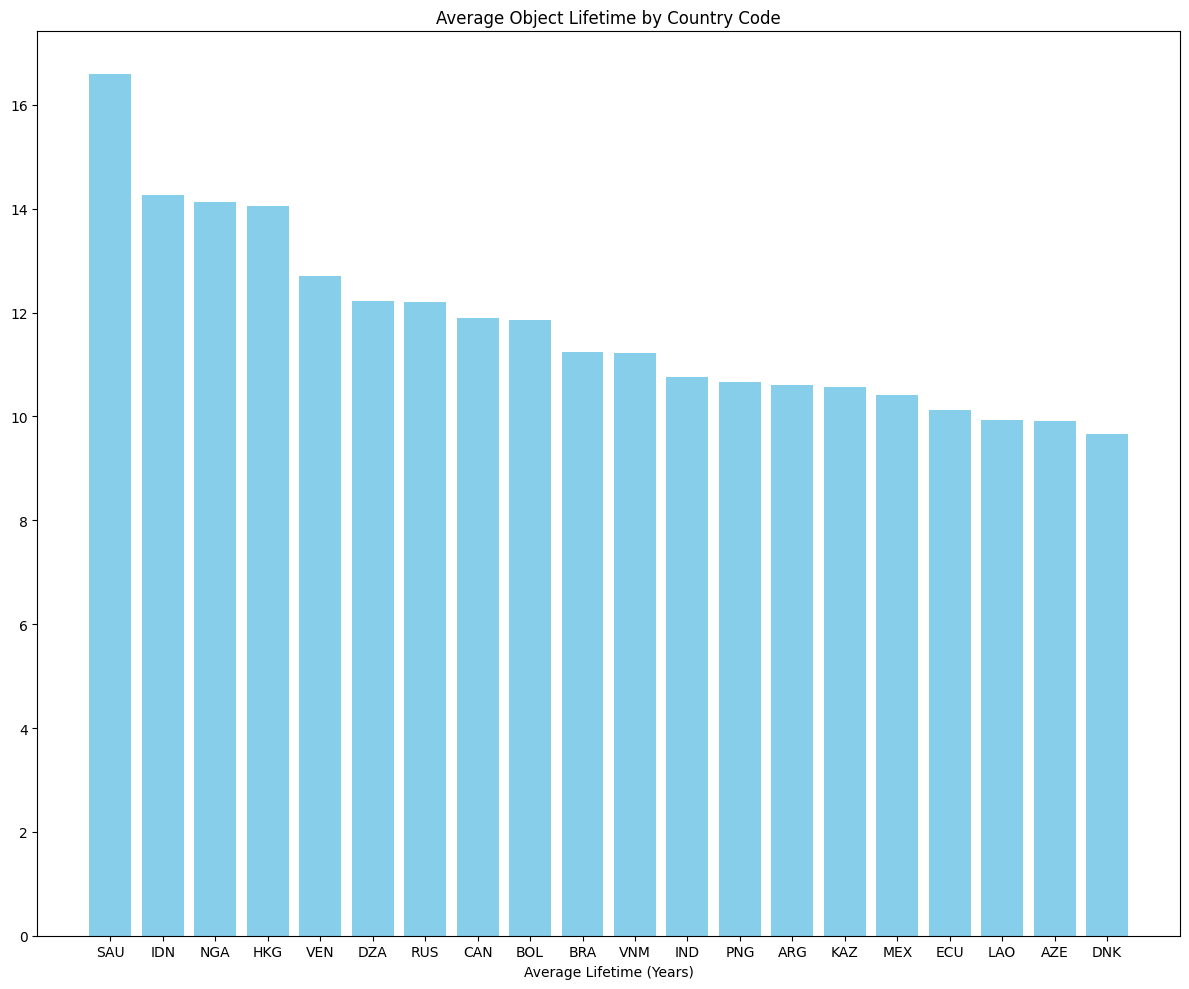

In [63]:
plt.figure(figsize=(12, 10))
plt.bar(avg_lifetime['CountryCode'], avg_lifetime['AvgLifetime'], color='skyblue')
plt.xlabel('Average Lifetime (Years)')
plt.title('Average Object Lifetime by Country Code')
plt.tight_layout()
plt.show()

In [38]:
# Filter non payloads
# sdf = sdf[sdf['Type'].str.startswith('P', na=False)]

<Figure size 1500x800 with 0 Axes>

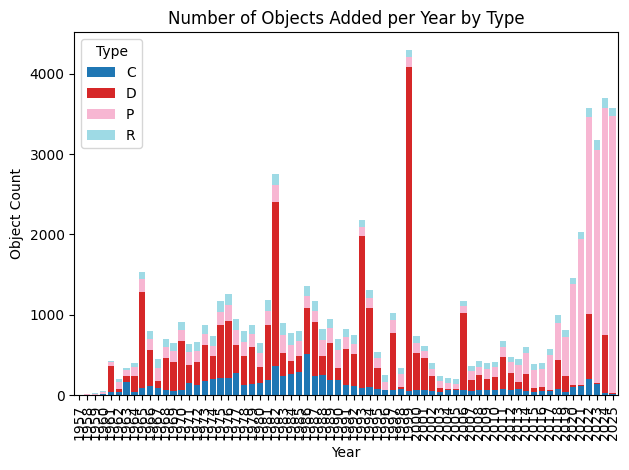

In [39]:
# Group by LYear and Type, then count
grouped = sdf.groupby(['LYear', 'Type']).size().unstack(fill_value=0).sort_index()

# Plotting
plt.figure(figsize=(15, 8))
grouped.plot(kind='bar', stacked=True, colormap='tab20', width=0.8)
plt.title('Number of Objects Added per Year by Type')
plt.xlabel('Year')
plt.ylabel('Object Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

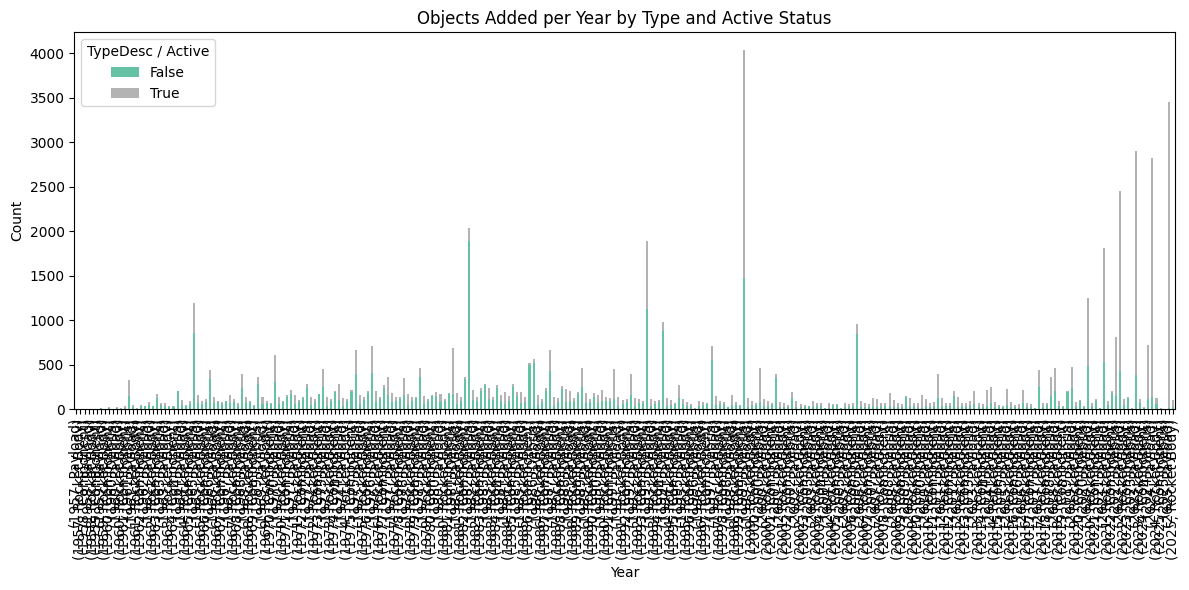

In [73]:
grouped = sdf.groupby(['LYear', 'TypeDesc', 'Active']).size().unstack(fill_value=0)

# Plotting
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Objects Added per Year by Type and Active Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='TypeDesc / Active')
plt.tight_layout()
plt.show()

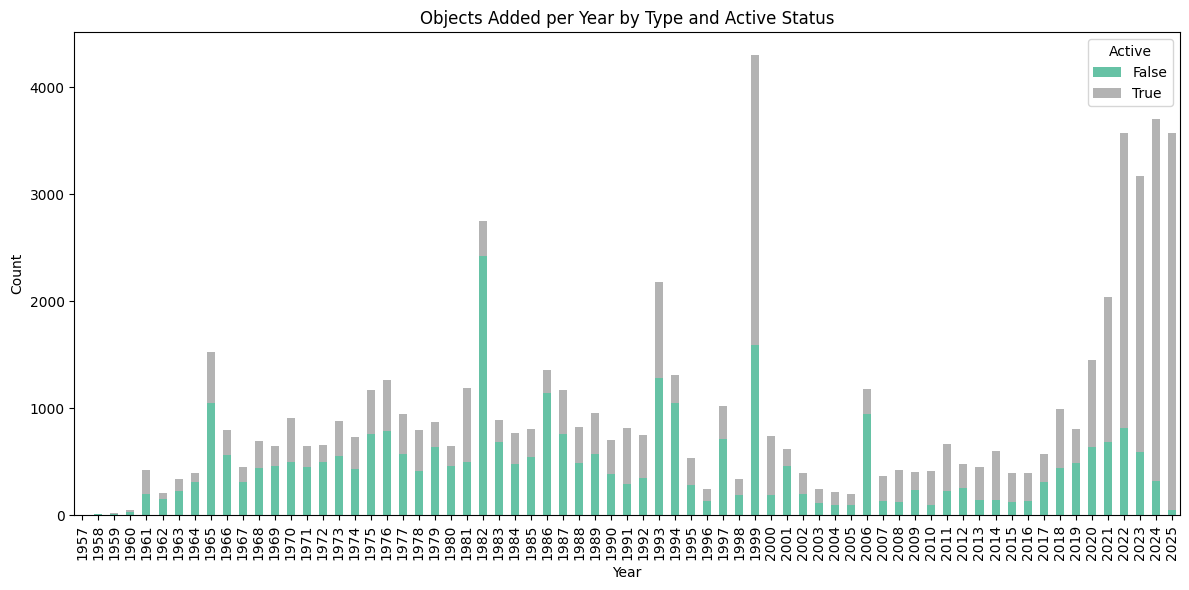

In [75]:
grouped = sdf.groupby(['LYear', 'Active']).size().unstack(fill_value=0)

# Plotting
grouped.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Objects Added per Year by Type and Active Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Active')
plt.tight_layout()
plt.show()

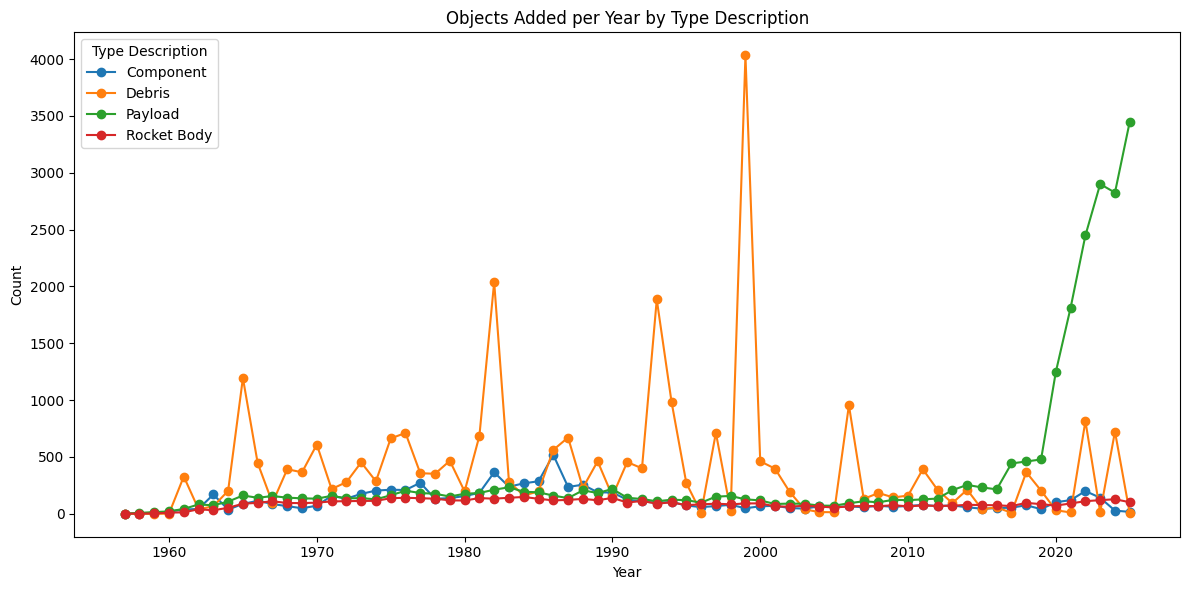

In [71]:
grouped = sdf.groupby(['LYear', 'TypeDesc']).size().unstack(fill_value=0).sort_index()

grouped.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Objects Added per Year by Type Description')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Type Description')
plt.tight_layout()
plt.show()

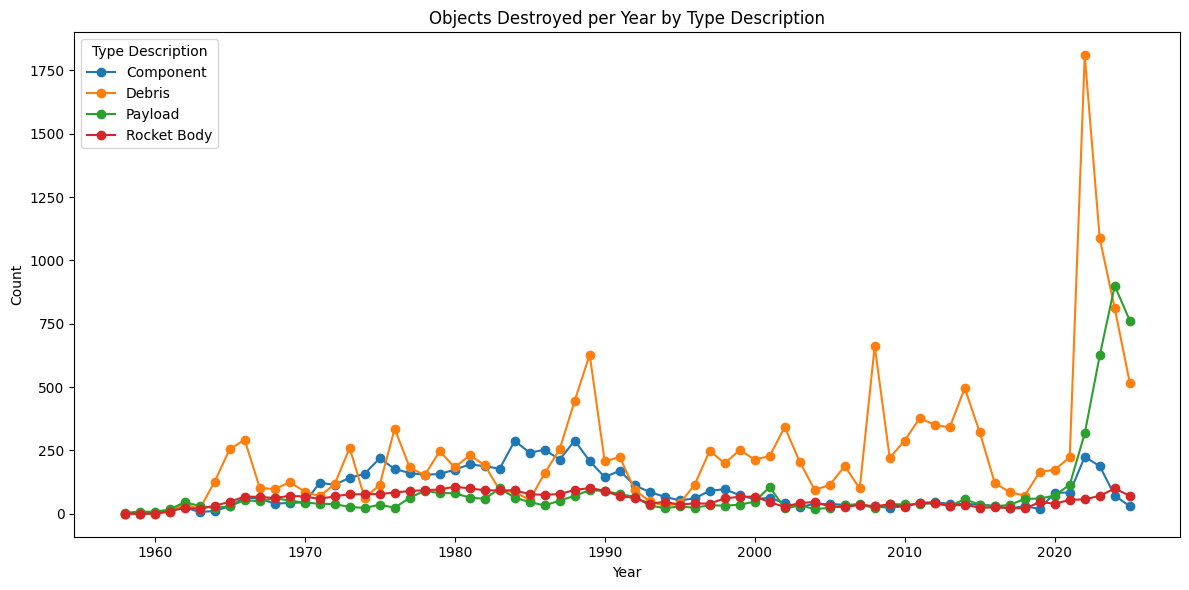

In [77]:
grouped = sdf.groupby(['DYear', 'TypeDesc']).size().unstack(fill_value=0).sort_index()

grouped.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Objects Destroyed per Year by Type Description')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Type Description')
plt.tight_layout()
plt.show()

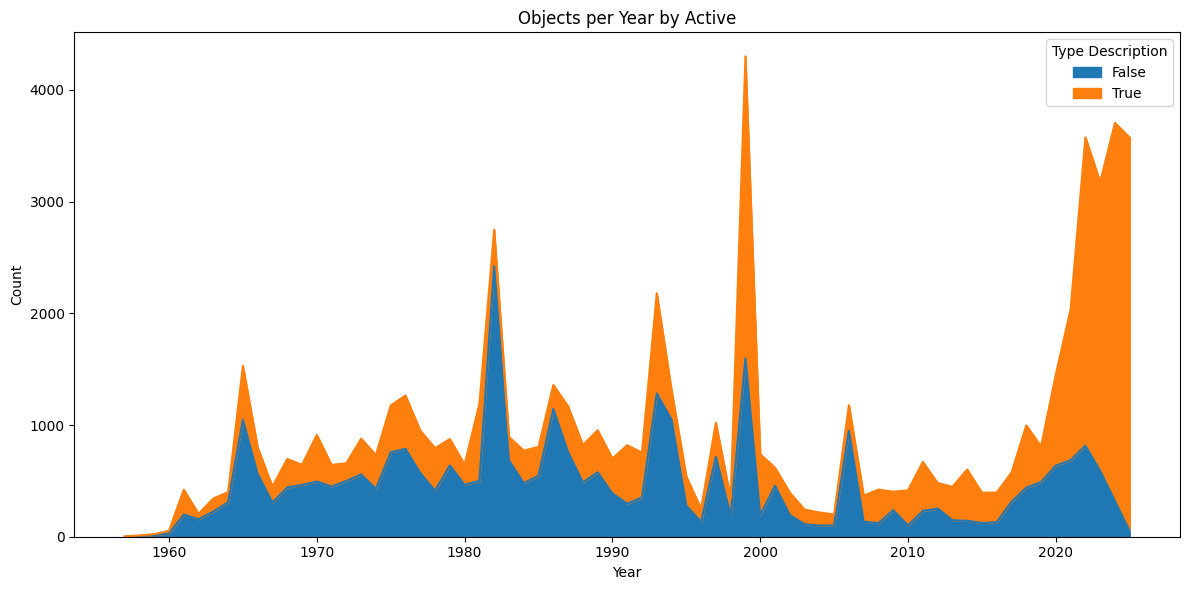

In [88]:
grouped = sdf.groupby(['LYear', 'Active']).size().unstack(fill_value=0).sort_index()

grouped.plot(kind='area',  figsize=(12, 6))
plt.title('Objects per Year by Active')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Type Description')
plt.tight_layout()
plt.show()

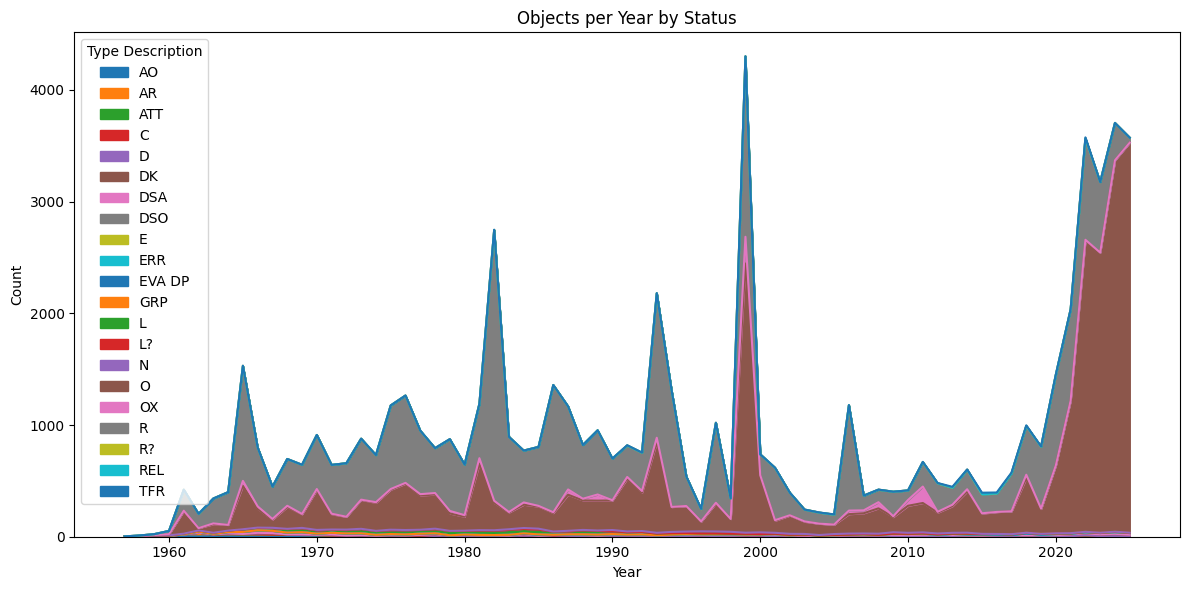

In [85]:
grouped = sdf.groupby(['LYear', 'Status']).size().unstack(fill_value=0).sort_index()

grouped.plot(kind='area',  figsize=(12, 6))
plt.title('Objects per Year by Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Type Description')
plt.tight_layout()
plt.show()

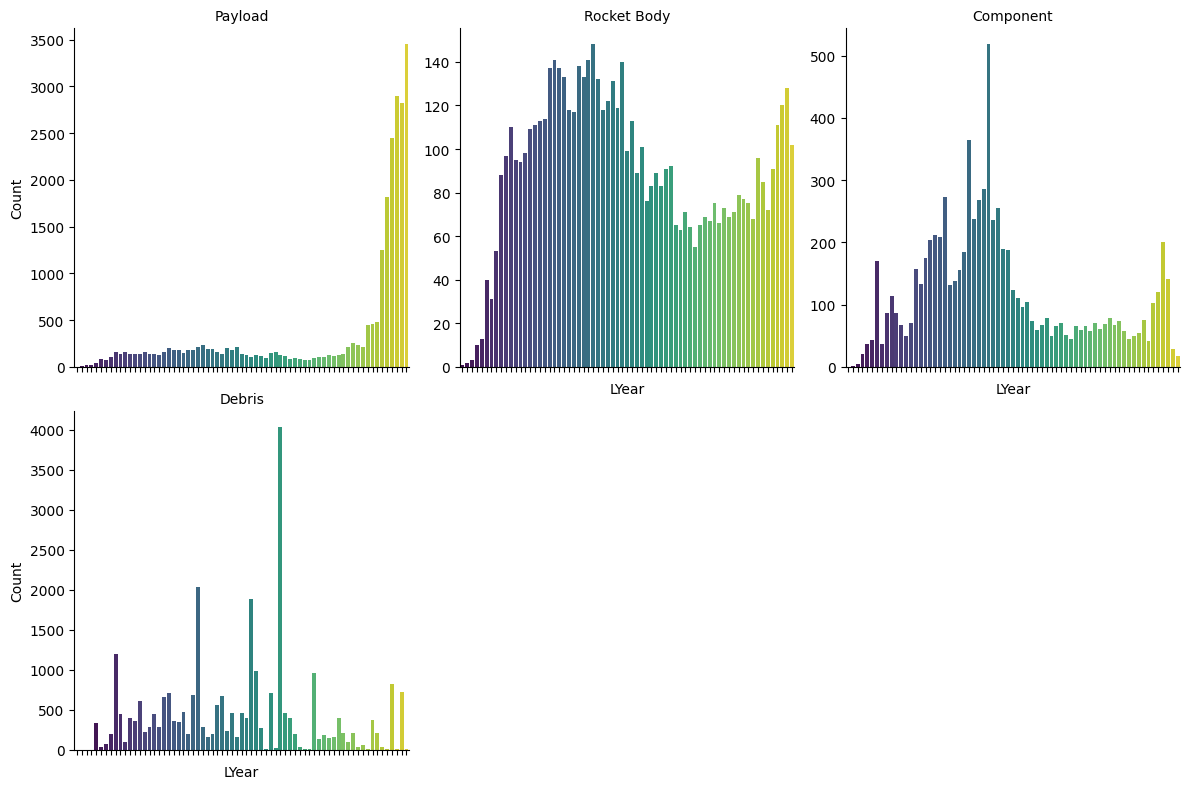

In [42]:
melted = sdf.groupby(['LYear', 'TypeDesc']).size().reset_index(name='Count')

# Plot
g = sns.FacetGrid(melted, col='TypeDesc', col_wrap=3, height=4, sharey=False)
g.map_dataframe(sns.barplot, x='LYear', y='Count', palette='viridis')
g.set_titles(col_template='{col_name}')
g.set_xticklabels(rotation=45)
plt.tight_layout()
plt.show()

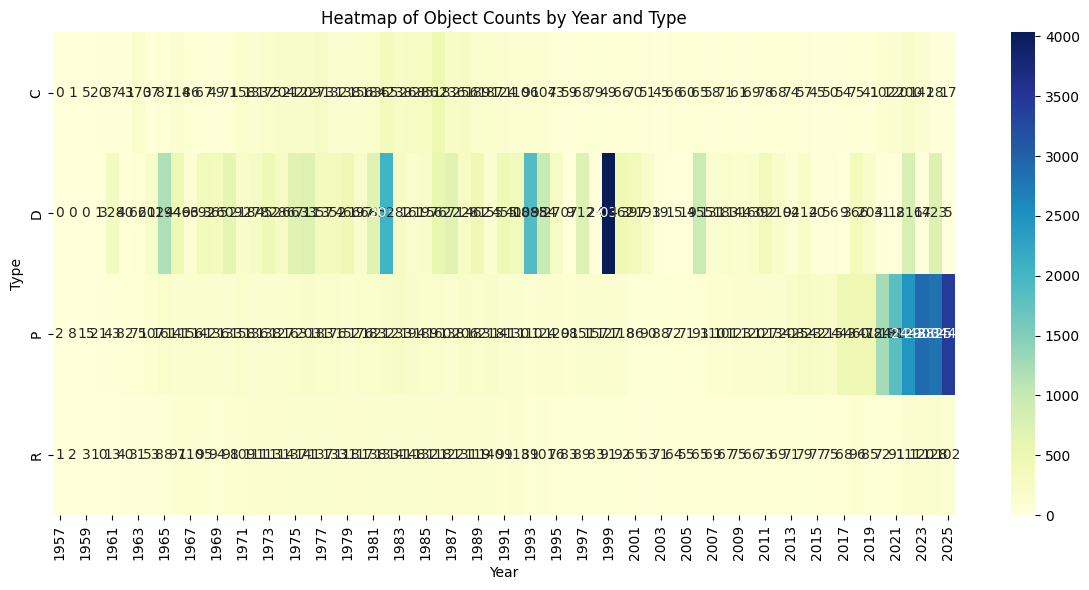

In [43]:
heatmap_data = sdf.groupby(['LYear', 'Type']).size().unstack(fill_value=0).sort_index()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data.T, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Heatmap of Object Counts by Year and Type')
plt.xlabel('Year')
plt.ylabel('Type')
plt.tight_layout()
plt.show()

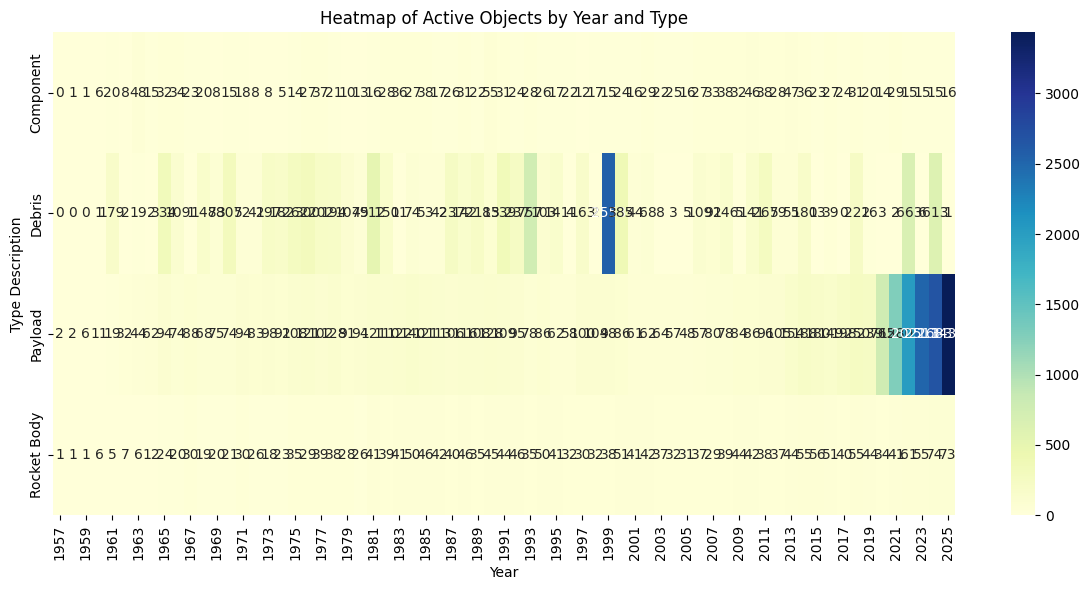

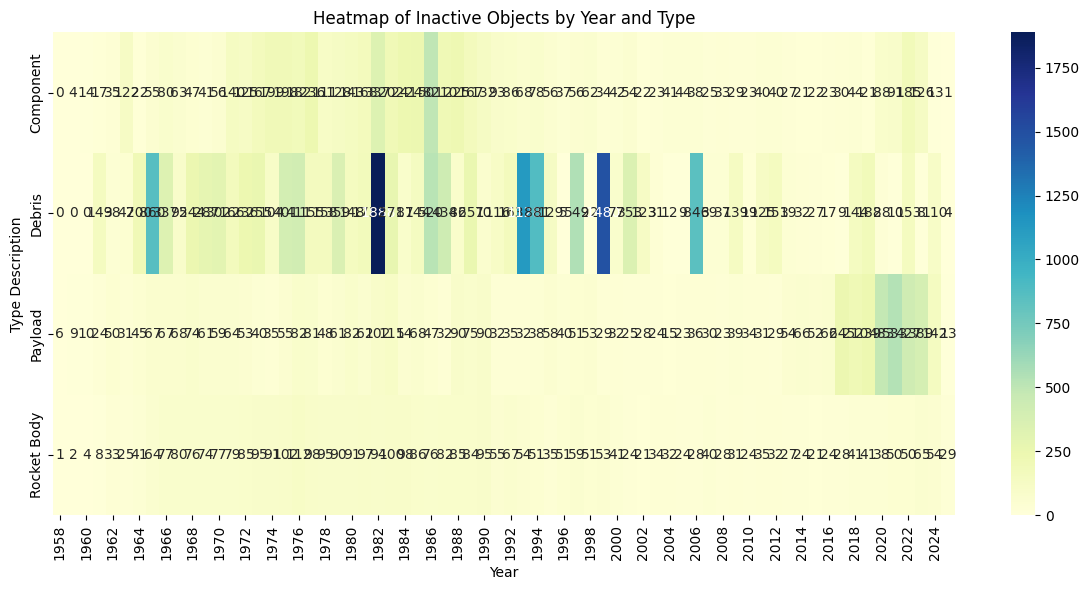

In [44]:
for status in [True, False]:
    subset = sdf[sdf['Active'] == status]
    heatmap_data = subset.groupby(['LYear', 'TypeDesc']).size().unstack(fill_value=0)

    plt.figure(figsize=(12, 6))
    sns.heatmap(heatmap_data.T, cmap='YlGnBu', annot=True, fmt='d')
    plt.title(f"Heatmap of {'Active' if status else 'Inactive'} Objects by Year and Type")
    plt.xlabel('Year')
    plt.ylabel('Type Description')
    plt.tight_layout()
    plt.show()

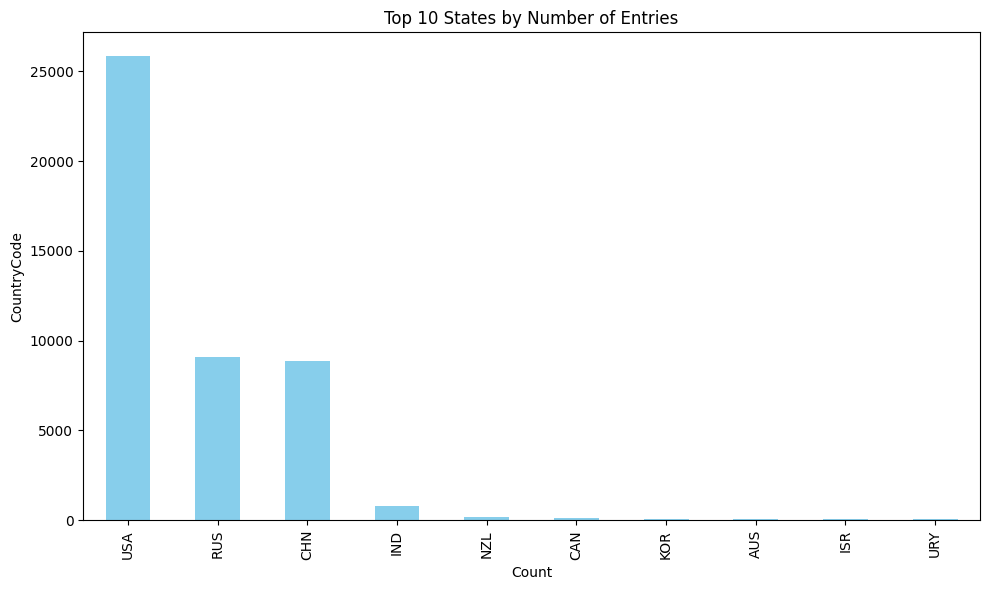

In [72]:
state_counts = sdf['CountryCode'].value_counts().head(10)

# Plotting a horizontal bar chart
plt.figure(figsize=(10, 6))
state_counts.plot(kind='bar', color='skyblue')
plt.title('Top 10 States by Number of Entries')
plt.xlabel('Count')
plt.ylabel('CountryCode')
plt.tight_layout()
plt.show()

In [46]:
owner_counts = sdf['Owner'].value_counts().reset_index()
owner_counts.columns = ['Owner', 'Count']
display(owner_counts)

,Owner,Count
0,SPXS,10397
1,CASC,4352
2,RVSN,4063
3,KVR,3116
4,GSFC,3107
...,...,...
1863,HYDRA/ICH,1
1864,HYDRA,1
1865,ARC/WI,1
1866,IMBP/GUKOSR,1


In [47]:
orgs_df.columns

Index(['#Code', 'UCode', 'StateCode', 'Type', 'Class', 'TStart', 'TStop',
       'ShortName', 'Name', 'Location', 'Longitude', 'Latitude', 'Error',
       'Parent', 'ShortEName', 'EName', 'UName'],
      dtype='object')

In [48]:
orgs_df.sample(n=20)

,#Code,UCode,StateCode,Type,Class,TStart,TStop,ShortName,Name,Location,Longitude,Latitude,Error,Parent,ShortEName,EName,UName
2337,NANR,NANR,US,O/PL,B,2008,-,NanoRacks,NanoRacks,"Houston, Texas",-95.3800,29.7600,0.02,-,-,-,NanoRacks
279,6555A,6555A,US,O/LA,D,-,-,USAF 6555ATW,USAF 6555 Aerospace Test Wing,"Cape Canaveral AFS, Florida",-80.6000,28.3900,0.02,USAF,-,-,USAF 6555 Aerospace Test Wing
2058,LPSP,LPSP,F,PL/S,C,-,-,LPSP,Laboratoire de Physique Stellaire et Planetair...,"Paris:Verrieres-le-Buisson, Essonne",2.2700,48.7500,0.02,CNRS,-,-,Laboratoire de Physique Stellaire et Planétair...
1972,LAOJV,LAOJV,LA,-,B,2015,-,LaoSat JVC,Lao Satellite Joint Venture Company,Vientiane,102.6000,17.9700,0.02,LANAST,-,-,Lao Satellite Joint Venture Co.
846,CALT,CALT,CN,O/LA/LV/PL/E/LS,C,1957 Nov 11,-,CALT,Zhongguo yunzaihuojian jishu yanjiu yuan,Beijing:Nanyuan,116.3900,39.7800,0.02,CASC,CALT,Chinese Academy of Launch Vehicle Technology (...,中国运载火箭技术研究院
1325,FIRMA,FIRMA,US,PL,B,2015,-,Firmamentum,Firmamentum,"Seattle:Bothell, Washington",-122.2000,47.7700,0.02,TUI,-,-,Firmamentum
1246,EPOS,EPOS,SU,O,B,1976,1978,MiG EPOS,Mikoyan i Gurevich OKB-155 EPOS,Aktyubinsk,59.6100,47.8500,0.02,MIG,-,-,ОКБ Микоян и Гуревич ЭПОС
847,CALTQ,CALTQ,CN,LA/LV,C,2015,-,CALT,Zhongguo yunzaihuojian jishu yanjiu yuan [CALT...,Qingdao,120.3100,36.0600,0.02,CALT,-,Chinese Academy of Launch Vehicle Technology (...,中国运载火箭技术研究院
1094,DEWC,DEWC,AU,O/S,B,2011,-,DEWC,DEWC Systems Pty Ltd.,Adelaide:Mawson Lakes,138.6100,-34.8200,0.02,UK,-,-,DEWC Systems Pty Ltd.
891,CEL,CEL,F,LA/LS/S,D,1967,2005,CEL,"Centre d'Essais de Landes, DGA","Biscarosse, France",-1.2500,44.4500,0.02,DGA,-,-,"Centre d'Essais de Landes, DGA"


In [49]:
orgs_columns_to_keep = ['#Code', 'UCode', 'ShortName', 'Name', 'EName', 'Longitude', 'Latitude', 'Parent']
odf = orgs_df[orgs_columns_to_keep]
odf.columns

Index(['#Code', 'UCode', 'ShortName', 'Name', 'EName', 'Longitude', 'Latitude',
       'Parent'],
      dtype='object')

In [50]:
# First, rename odf columns for owner merge
owner_odf = odf.rename(columns=lambda x: f'owner_{x}' if x != '#Code' else 'Owner')

# Merge owner info
sdf = sdf.merge(owner_odf, on='Owner', how='left')

# Optional: repeat for manufacturer with a different prefix
manufacturer_odf = odf.rename(columns=lambda x: f'manu_{x}' if x != '#Code' else 'Manufacturer')
sdf = sdf.merge(manufacturer_odf, on='Manufacturer', how='left')


In [51]:
sdf.columns

Index(['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State',
       'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape',
       'Perigee', 'Apogee', 'Inc', 'LYear', 'DYear', 'EffectiveDDate',
       'ActiveDays', 'ActiveMonths', 'ActiveYears', 'CountryCode', 'TypeDesc',
       'Active', 'owner_UCode', 'owner_ShortName', 'owner_Name', 'owner_EName',
       'owner_Longitude', 'owner_Latitude', 'owner_Parent', 'manu_UCode',
       'manu_ShortName', 'manu_Name', 'manu_EName', 'manu_Longitude',
       'manu_Latitude', 'manu_Parent'],
      dtype='object')

In [52]:
sdf.sample(10)

,Piece,Type,Name,LDate,DDate,Status,Owner,State,Manufacturer,Mass,...,owner_Longitude,owner_Latitude,owner_Parent,manu_UCode,manu_ShortName,manu_Name,manu_EName,manu_Longitude,manu_Latitude,manu_Parent
65946,2025-232AC,P,Starlink 35326,16/10/2025,NaN,O,SPXS,US,SPXS,575.0,...,-122.1200,47.6700,-,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-
62465,2025-005Q,P,USA 477,10/01/2025,NaN,O,NROC,US,SPXS,800,...,-77.4000,38.8800,-,SPXS,SpaceX/Seattle,SpaceX (Seattle),-,-122.1200,47.6700,-
24609,1994-029AAJ,D,deb HAPS,19/05/1994,10/11/1997,R,OSCC,US,-,0.0,...,-111.8300,33.3000,OSC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29592,2006-039R,D,deb Kosmos-2423,14/09/2006,19/11/2006,R,KVR,RU,-,0.0,...,36.9800,56.1800,MORF,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24437,1994-029TF,D,deb HAPS,19/05/1994,31/12/2000,R,OSCC,US,-,0.0,...,-111.8300,33.3000,OSC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10342,1977-042P,P,Kosmos-913 SS 12,30/05/1977,18/04/1978,R,PVO,SU,YUZH,5.0,...,37.6200,55.7500,-,YUZH,Yuzhnoe,KB Yuzhnoe im. M K Yangel,Southern State Design Bureau,34.9800,48.4500,-
27734,1994-029AEN,D,deb HAPS,19/05/1994,06/01/2004,R,OSCC,US,-,0.0,...,-111.8300,33.3000,OSC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30404,1998-067AS,C,EVA debris,11/09/2006,10/03/2007,R,JSC,US,-,0.0,...,-95.1200,29.5600,NASA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4525,1970-072A,P,Luna-16 KT,12/09/1970,NaN,DSO,IKI/BABTS,SU,BABTS,3180.0,...,NaN,NaN,NaN,BABTS,Babakin,Babakin Science and Research Space Center,-,37.4500,55.9000,NPOL
3147,1968-018A,P,OPS 5057,13/03/1968,NaN,AR,NRO/SAFSP,US,LMSC,2250.0,...,NaN,NaN,NaN,LMSC,LMSC,Lockheed Missiles and Space Co.,-,-122.0400,37.3700,LAC


In [53]:
pay_df.columns

Index(['#JCAT', 'Piece', 'Name', 'LDate', 'TLast', 'TOp', 'TDate', 'TF',
       'Program', 'Plane', 'Att', 'Mvr', 'Class', 'Category', 'Result',
       'Control', 'Discipline', 'UNState', 'UNReg', 'UNPeriod', 'UNPerigee',
       'UNApogee', 'UNInc', 'DispEpoch', 'DispPeri', 'DispApo', 'DispInc',
       'Comment'],
      dtype='object')

In [54]:
payload_columns_to_keep = ['Piece', 'Program', 'Class', 'Category']
pdf = pay_df[payload_columns_to_keep]
pdf.columns

Index(['Piece', 'Program', 'Class', 'Category'], dtype='object')

In [55]:
sdf = sdf.merge(pdf, on='Piece', how='left')

In [56]:
sdf.columns

Index(['Piece', 'Type', 'Name', 'LDate', 'DDate', 'Status', 'Owner', 'State',
       'Manufacturer', 'Mass', 'Length', 'Diameter', 'Span', 'Shape',
       'Perigee', 'Apogee', 'Inc', 'LYear', 'DYear', 'EffectiveDDate',
       'ActiveDays', 'ActiveMonths', 'ActiveYears', 'CountryCode', 'TypeDesc',
       'Active', 'owner_UCode', 'owner_ShortName', 'owner_Name', 'owner_EName',
       'owner_Longitude', 'owner_Latitude', 'owner_Parent', 'manu_UCode',
       'manu_ShortName', 'manu_Name', 'manu_EName', 'manu_Longitude',
       'manu_Latitude', 'manu_Parent', 'Program', 'Class', 'Category'],
      dtype='object')

In [57]:
sdf.sample(10)

,Piece,Type,Name,LDate,DDate,Status,Owner,State,Manufacturer,Mass,...,manu_UCode,manu_ShortName,manu_Name,manu_EName,manu_Longitude,manu_Latitude,manu_Parent,Program,Class,Category
43578,2018-067A,P,Beidou DW 36,24/08/2018,NaN,O,CNSA,CN,SECM,1014,...,SECM,SECM,Shanghai weixiao weixing gongcheng zhongxin,Shanghai Engineering Center for Microsatellite...,121.4700,31.2300,SIMIT,Beidou-3M2,D,NAV
4847,1971-003A,P,Meteor,20/01/1971,14/06/2005,R,GUKOSR/GMS,SU,VNIEM,1280.0,...,VNIEM,VNIIEM,Vsesoyuzniy nauchno-issledovatel'skiy institut...,All-Union Electromechanical Scientific Researc...,37.6200,55.7500,METP,Meteor C,D,MET
40416,1995-015AS,D,deb DMSP F-13,24/03/1995,06/10/2015,R,AFSMC,US,-,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11707,1980-004B,R,Centaur AC-49,18/01/1980,05/01/1990,R,LERC,US,GDC,2000.0,...,CONV,GD/Convair,General Dynamics/Convair Division (Plant 19),-,-117.1900,32.7300,GD,NaN,NaN,NaN
30251,1999-025YL,D,deb FY-1C,10/05/1999,NaN,O,CASC,CN,-,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34296,1993-036NS,D,deb Kosmos-2251,16/06/1993,26/07/2012,R,KVR,RU,-,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32336,1999-025CZD,D,deb FY-1C,10/05/1999,NaN,O,CASC,CN,-,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64555,2024-140AED,D,deb CZ-6A Y21,06/08/2024,NaN,O,CNSA,CN,SAST,0,...,SBA,SAST,Shanghai hangtian jishu yanjiuyuan,Shanghai Academy of Space Technology (CASC 8th...,121.3800,31.1100,CASC,NaN,NaN,NaN
21534,1991-047D,R,Delta 206 Stage 3,04/07/1991,11/09/1995,R,MDAC,US,THKE,2141.0,...,THKE,Thiokol/TE,Thiokol-Elkton,-,-75.8300,39.6100,THK,NaN,NaN,NaN
10485,1977-109B,R,Kosmos-3M 46-302 Stage 2,24/11/1977,NaN,O,RVSN,SU,OAZ,1434.0,...,POL,Omsk Av. Zav.,KB Omsk Aviatsionniy Zavod,Omsk Aviation Plant,73.3700,54.9800,-,NaN,NaN,NaN


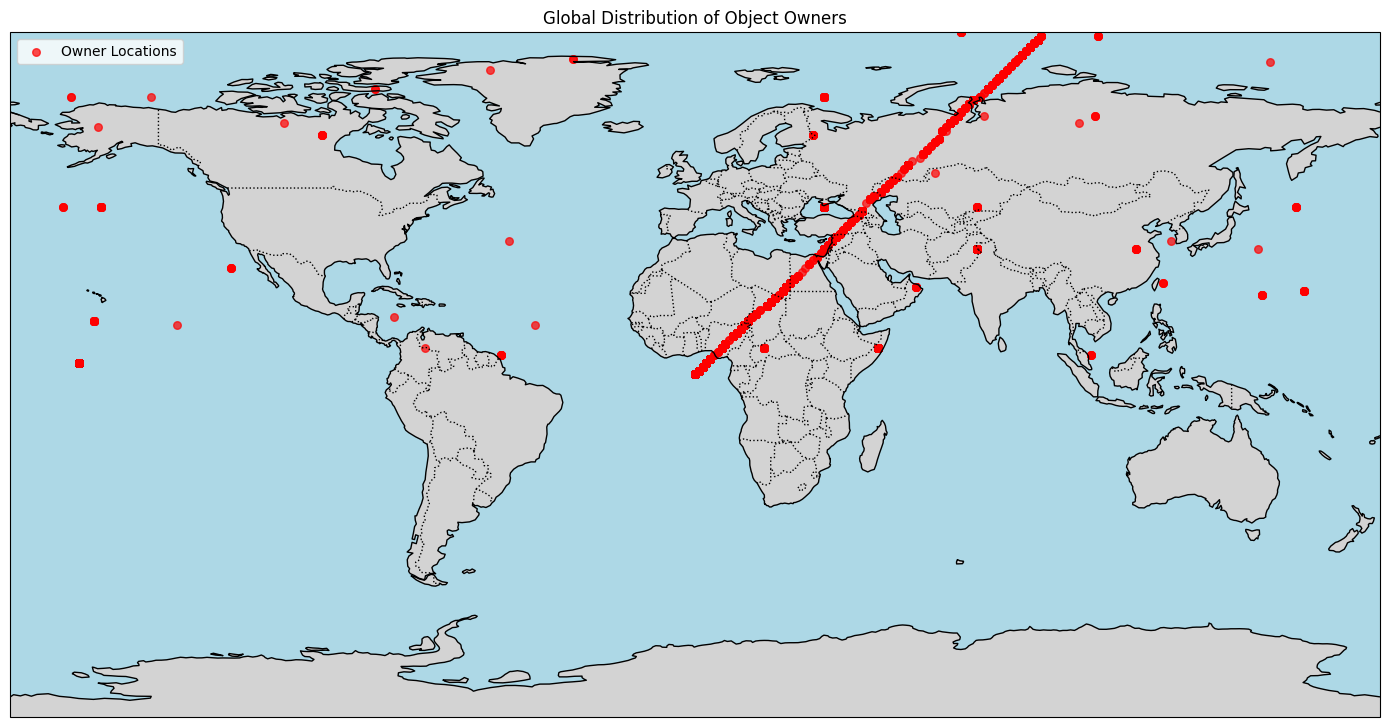

In [58]:
# Drop rows with missing coordinates
sdf_clean = sdf.dropna(subset=['owner_Latitude', 'owner_Longitude'])

# Create the map
plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Plot points
ax.scatter(
    sdf_clean['owner_Longitude'],
    sdf_clean['owner_Latitude'],
    color='red',
    s=30,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    label='Owner Locations'
)

plt.title('Global Distribution of Object Owners')
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")


In [60]:
# Count satellites per country
state_counts = sdf['CountryCode'].value_counts().reset_index()

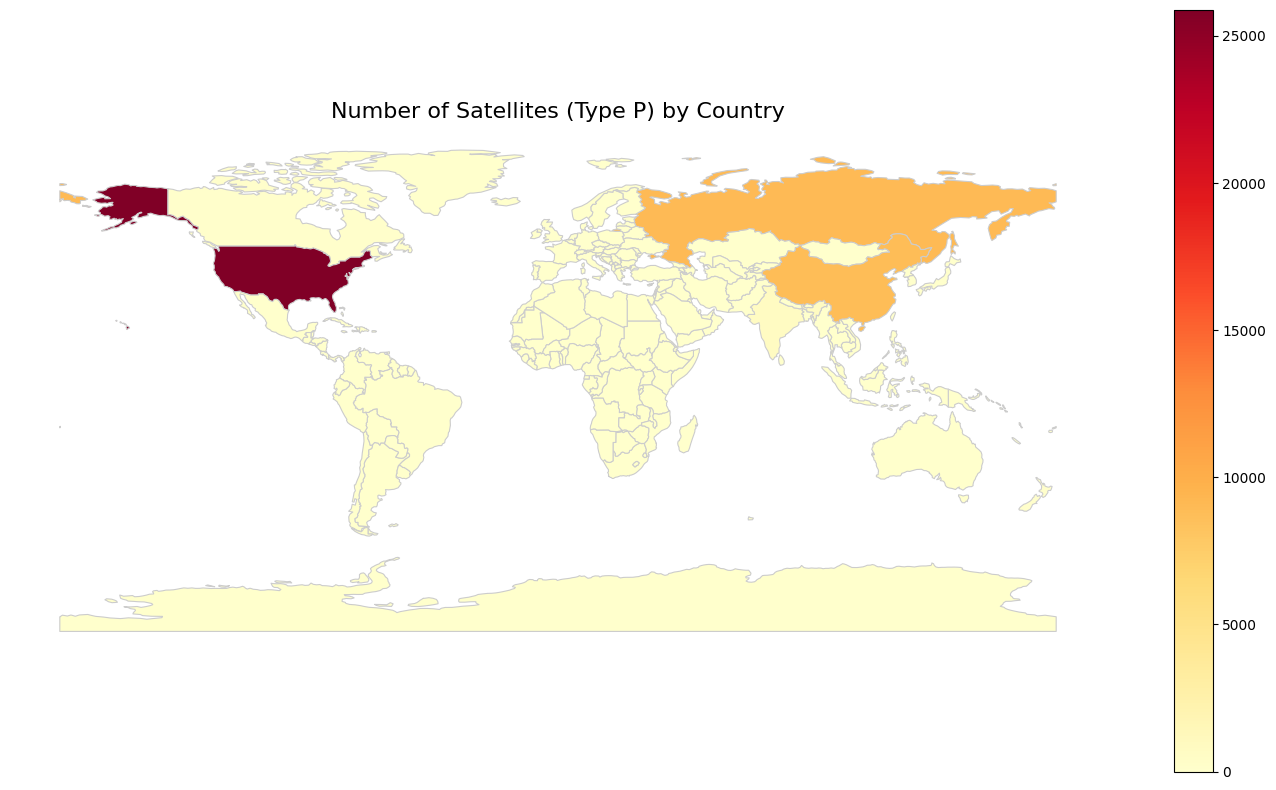

In [61]:


state_counts.columns = ['ADM0_ISO', 'SatelliteCount']

# Load world map with ISO codes
world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
#world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Merge using ISO alpha-3 codes
merged = world.merge(state_counts, on='ADM0_ISO', how='left')

# Fill missing counts with 0
merged['SatelliteCount'] = merged['SatelliteCount'].fillna(0)

# Plotting
fig, ax = plt.subplots(figsize=(14, 8))
merged.plot(column='SatelliteCount', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Number of Satellites (Type P) by Country', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

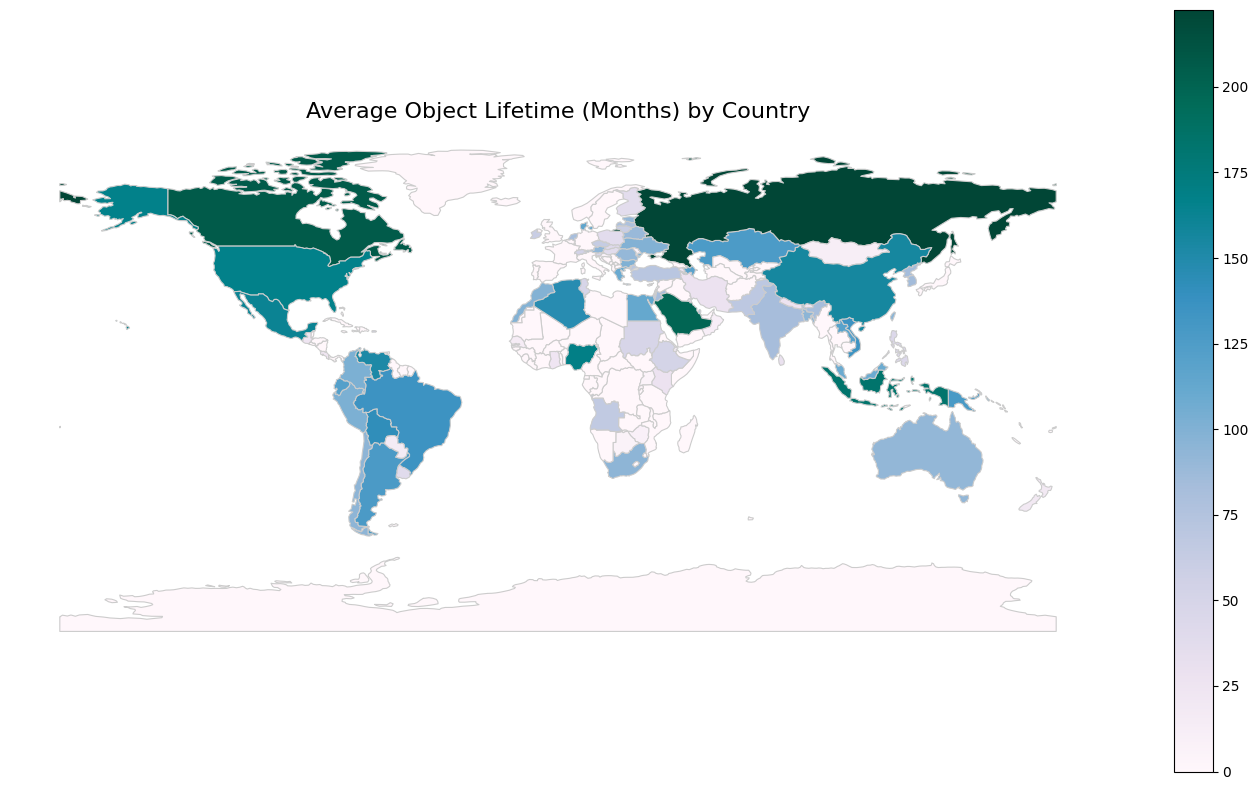

In [62]:
avg_months = sdf.groupby('CountryCode')['ActiveMonths'].mean().reset_index()
avg_months.columns = ['ADM0_A3', 'AvgMonths']
merged = world.merge(avg_months, on='ADM0_A3', how='left')
merged['AvgMonths'] = merged['AvgMonths'].fillna(0)
fig, ax = plt.subplots(figsize=(14, 8))
merged.plot(column='AvgMonths', cmap='PuBuGn', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Average Object Lifetime (Months) by Country', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()